# PRIMARY GOAL: Credit Default Risk Prediction

This notebook focuses on predicting whether a credit applicant will default on their loan. We'll compare multiple machine learning models to find the best predictor of credit risk.

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, accuracy_score, recall_score, precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.filterwarnings('ignore')

# Create plots folder
if not os.path.exists('plots'):
    os.makedirs('plots')
print("✓ Plots folder created")

# Configuration
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load and clean data
df = pd.read_csv('german_credit_data.csv', index_col=0)
df = df.replace('NA', np.nan)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown', inplace=True)

print(f"Dataset loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")

✓ Plots folder created
Dataset loaded: (1000, 9)
Columns: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']


## 2. Create Target Variable - Credit Default Risk

Default Risk Distribution:
DEFAULT_RISK
0    702
1    298
Name: count, dtype: int64

Default Rate: 29.80%
Non-Default: 70.20%


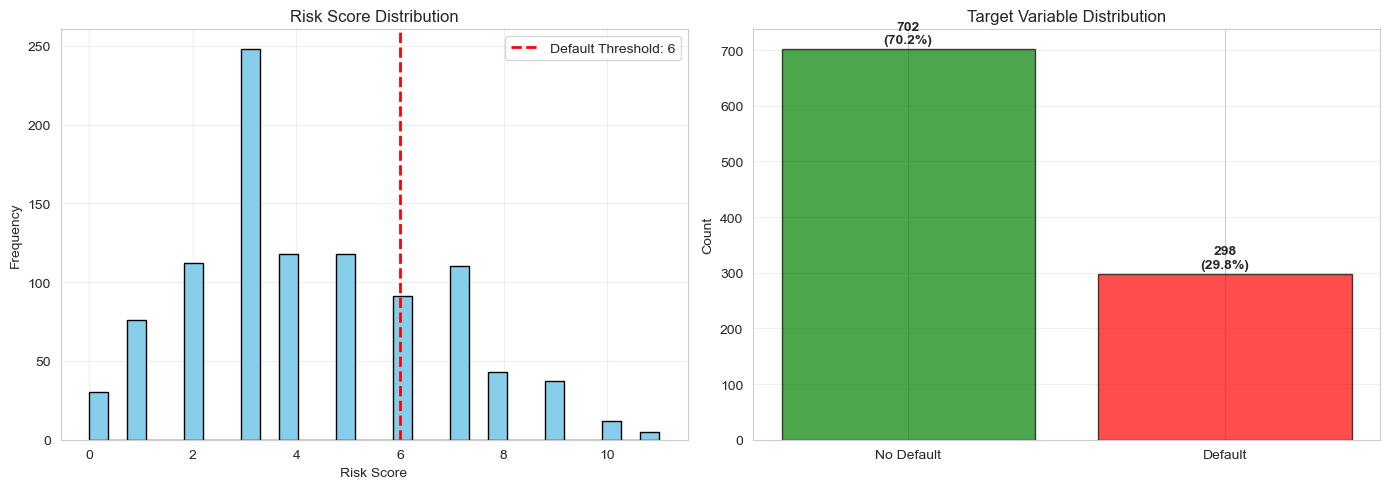

✓ Saved: plots/01_default_risk_distribution.png


In [2]:
# Create a synthetic DEFAULT_RISK target variable based on risk factors
# Risk factors: Long duration, high credit, poor financial health, young age, unstable job

df_ml = df.copy()

# Initialize risk score
risk_score = 0

# Risk Factor 1: High Credit Amount (>75th percentile)
high_credit_threshold = df_ml['Credit amount'].quantile(0.75)
risk_score += (df_ml['Credit amount'] > high_credit_threshold).astype(int) * 2

# Risk Factor 2: Long Duration (>75th percentile)
long_duration_threshold = df_ml['Duration'].quantile(0.75)
risk_score += (df_ml['Duration'] > long_duration_threshold).astype(int) * 2

# Risk Factor 3: Young Age (<25)
risk_score += (df_ml['Age'] < 25).astype(int) * 3

# Risk Factor 4: Unstable Job (Job Level 0 or 3 - unskilled/skilled)
risk_score += ((df_ml['Job'] == 0) | (df_ml['Job'] == 3)).astype(int) * 2

# Risk Factor 5: No Housing Ownership (not owning home)
risk_score += (df_ml['Housing'] != 'own').astype(int) * 1

# Risk Factor 6: No Savings
risk_score += (df_ml['Saving accounts'] == 'little').astype(int) * 2

# Risk Factor 7: No Checking Account
risk_score += (df_ml['Checking account'] == 'little').astype(int) * 1

# Create binary DEFAULT target: High risk if score >= 7 (approximately 20-30% default rate)
default_threshold = risk_score.quantile(0.75)
df_ml['DEFAULT_RISK'] = (risk_score >= default_threshold).astype(int)

print("Default Risk Distribution:")
print("="*50)
print(df_ml['DEFAULT_RISK'].value_counts())
print(f"\nDefault Rate: {df_ml['DEFAULT_RISK'].mean()*100:.2f}%")
print(f"Non-Default: {(1-df_ml['DEFAULT_RISK']).mean()*100:.2f}%")


# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk score distribution
axes[0].hist(risk_score, bins=30, edgecolor='black', color='skyblue')
axes[0].axvline(default_threshold, color='red', linestyle='--', linewidth=2, label=f'Default Threshold: {default_threshold:.0f}')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Risk Score Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Default distribution
colors = ['green', 'red']
default_counts = df_ml['DEFAULT_RISK'].value_counts().sort_index()
axes[1].bar(['No Default', 'Default'], default_counts.values, color=colors, edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Count')
axes[1].set_title('Target Variable Distribution')
for i, v in enumerate(default_counts.values):
    axes[1].text(i, v + 10, f'{v}\n({v/len(df_ml)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/01_default_risk_distribution.png', dpi=300, bbox_inches='tight')

plt.show()
print("✓ Saved: plots/01_default_risk_distribution.png")

## 3. Feature Engineering & Preprocessing

In [3]:
# Encode categorical variables
df_encoded = df_ml.copy()

# Label encode categorical features
categorical_features = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print(df_encoded.sample(4))


# Select features for modeling
feature_cols = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 
                 'Checking account', 'Credit amount', 'Duration', 'Purpose']

X = df_encoded[feature_cols]
y = df_encoded['DEFAULT_RISK']

print("Features prepared:")
print(f"Shape: X={X.shape}, y={y.shape}")
print(f"\nFeatures: {list(X.columns)}")
print(f"\nFeature Statistics:")
print(X.describe())

     Age  Sex  Job  Housing  Saving accounts  Checking account  Credit amount  \
268   45    1    3        1                0                 0           8978   
165   32    1    2        1                2                 0           2978   
862   35    0    2        1                0                 0           2439   
241   51    1    2        1                0                 0           1595   

     Duration  Purpose  DEFAULT_RISK  
268        14        1             1  
165         6        4             0  
862        24        5             0  
241         6        5             0  
Features prepared:
Shape: X=(1000, 9), y=(1000,)

Features: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']

Feature Statistics:
               Age          Sex          Job      Housing  Saving accounts  \
count  1000.000000  1000.000000  1000.000000  1000.000000      1000.000000   
mean     35.546000     0.690000     1.904000     1

## 4. Train-Test Split & Feature Scaling

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution (Train):")
print(y_train.value_counts())
print(f"\nClass distribution (Test):")
print(y_test.value_counts())

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print(f"\nFeatures scaled successfully!")

Training set: (800, 9)
Test set: (200, 9)

Class distribution (Train):
DEFAULT_RISK
0    562
1    238
Name: count, dtype: int64

Class distribution (Test):
DEFAULT_RISK
0    140
1     60
Name: count, dtype: int64

Features scaled successfully!


## 5. Train Multiple Models

In [5]:
# Dictionary to store models and results
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True),
    'Naive Bayes': GaussianNB()
}

results = {}

print("\n" + "="*80)
print("TRAINING DEFAULT RISK PREDICTION MODELS")
print("="*80)

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    
    results[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc_roc': auc_roc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ Precision: {precision:.4f}")
    print(f"  ✓ Recall: {recall:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")
    print(f"  ✓ AUC-ROC: {auc_roc:.4f}")
    print(f"  ✓ CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


TRAINING DEFAULT RISK PREDICTION MODELS

Training Logistic Regression...
  ✓ Accuracy: 0.8400
  ✓ Precision: 0.7917
  ✓ Recall: 0.6333
  ✓ F1-Score: 0.7037
  ✓ AUC-ROC: 0.9035
  ✓ CV AUC: 0.8816 (+/- 0.0221)

Training Decision Tree...
  ✓ Accuracy: 0.9150
  ✓ Precision: 0.9388
  ✓ Recall: 0.7667
  ✓ F1-Score: 0.8440
  ✓ AUC-ROC: 0.8726
  ✓ CV AUC: 0.9467 (+/- 0.0146)

Training Random Forest...
  ✓ Accuracy: 0.9600
  ✓ Precision: 0.9483
  ✓ Recall: 0.9167
  ✓ F1-Score: 0.9322
  ✓ AUC-ROC: 0.9911
  ✓ CV AUC: 0.9940 (+/- 0.0040)

Training Gradient Boosting...
  ✓ Accuracy: 0.9750
  ✓ Precision: 1.0000
  ✓ Recall: 0.9167
  ✓ F1-Score: 0.9565
  ✓ AUC-ROC: 0.9944
  ✓ CV AUC: 0.9952 (+/- 0.0037)

Training SVM...
  ✓ Accuracy: 0.9300
  ✓ Precision: 0.9259
  ✓ Recall: 0.8333
  ✓ F1-Score: 0.8772
  ✓ AUC-ROC: 0.9725
  ✓ CV AUC: 0.9582 (+/- 0.0124)

Training Naive Bayes...
  ✓ Accuracy: 0.8700
  ✓ Precision: 0.8269
  ✓ Recall: 0.7167
  ✓ F1-Score: 0.7679
  ✓ AUC-ROC: 0.9335
  ✓ CV AUC: 0.9051 (+

## 6. Model Comparison & Best Model Selection


Model Performance Comparison:
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC  CV AUC
Logistic Regression     0.840     0.7917  0.6333    0.7037   0.9035  0.8816
Decision Tree           0.915     0.9388  0.7667    0.8440   0.8726  0.9467
Random Forest           0.960     0.9483  0.9167    0.9322   0.9911  0.9940
Gradient Boosting       0.975     1.0000  0.9167    0.9565   0.9944  0.9952
SVM                     0.930     0.9259  0.8333    0.8772   0.9725  0.9582
Naive Bayes             0.870     0.8269  0.7167    0.7679   0.9335  0.9051

✓ BEST MODEL: Gradient Boosting (AUC-ROC: 0.9944)


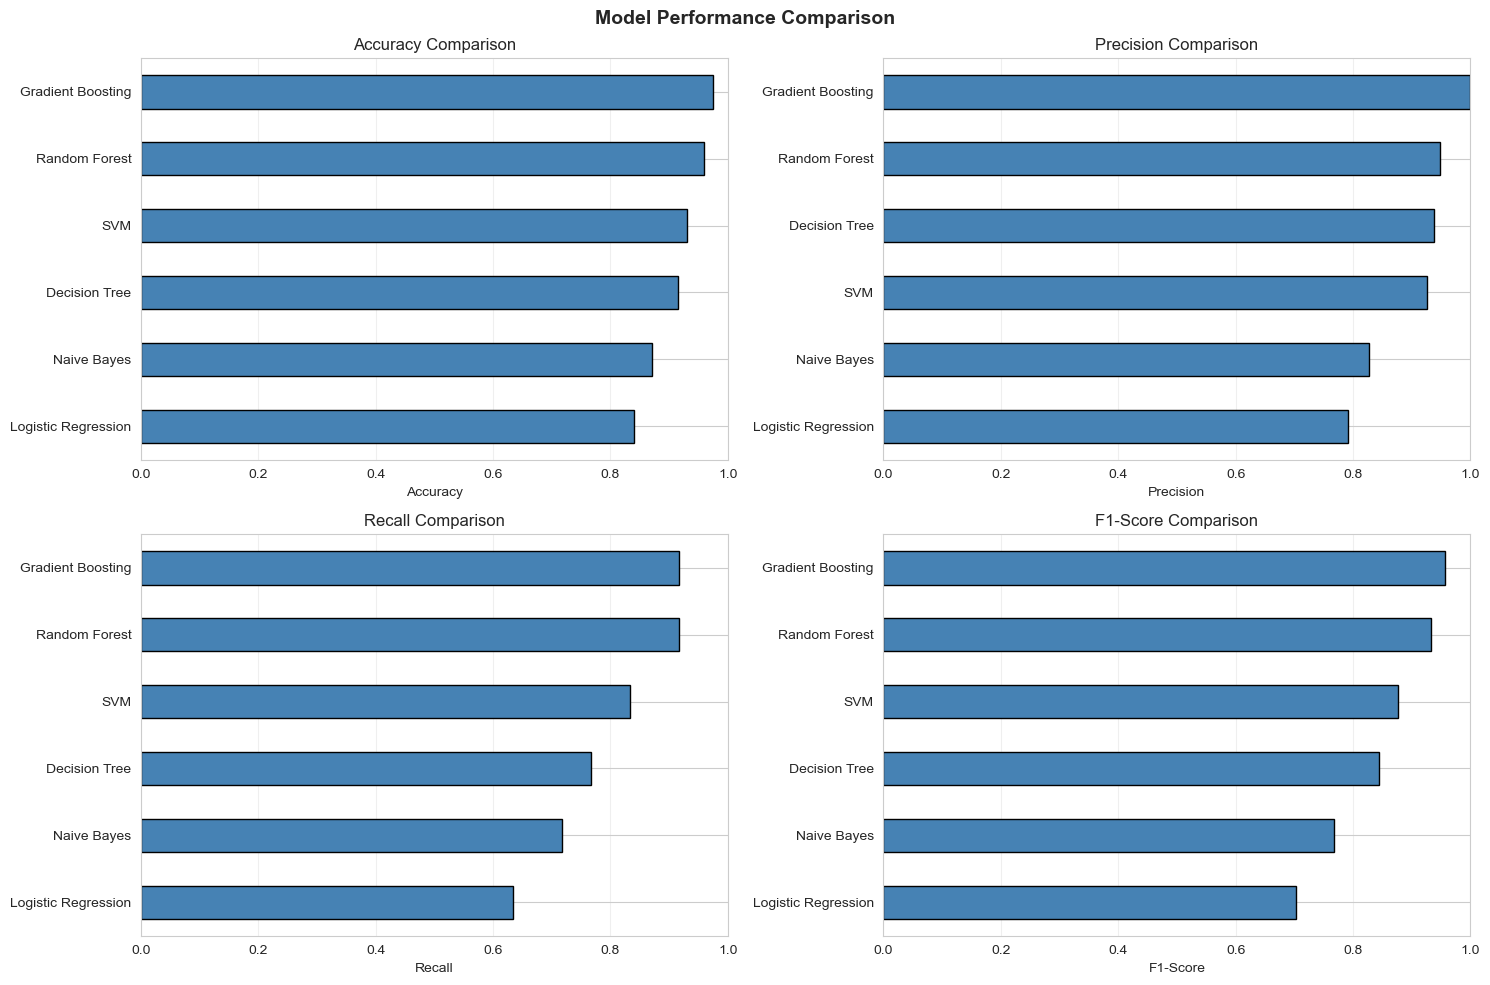

✓ Saved: plots/02_model_performance_comparison.png


In [6]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1'] for m in results],
    'AUC-ROC': [results[m]['auc_roc'] for m in results],
    'CV AUC': [results[m]['cv_mean'] for m in results]
}, index=results.keys())

print("\nModel Performance Comparison:")
print("="*80)
print(comparison_df.round(4))

# Find best model
best_model_name = comparison_df['AUC-ROC'].idxmax()
best_model = results[best_model_name]['model']

print(f"\n✓ BEST MODEL: {best_model_name} (AUC-ROC: {comparison_df.loc[best_model_name, 'AUC-ROC']:.4f})")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    comparison_df[metric].sort_values().plot(kind='barh', ax=ax, edgecolor='black', color='steelblue')
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.grid(True, alpha=0.3, axis='x')
    ax.set_xlim([0, 1])

plt.tight_layout()
plt.savefig('plots/02_model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: plots/02_model_performance_comparison.png")

## 7. Best Model Detailed Analysis

In [7]:
print(f"\n{'='*80}")
print(f"DETAILED ANALYSIS: {best_model_name}")
print(f"{'='*80}")

y_pred_best = results[best_model_name]['y_pred']
y_pred_proba_best = results[best_model_name]['y_pred_proba']

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, 
                          target_names=['No Default', 'Default']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_best)
print(cm)
print(f"\nTrue Negatives: {cm[0,0]} (Correctly predicted No Default)")
print(f"False Positives: {cm[0,1]} (Incorrectly predicted Default)")
print(f"False Negatives: {cm[1,0]} (Missed Defaults)")
print(f"True Positives: {cm[1,1]} (Correctly predicted Default)")


DETAILED ANALYSIS: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

  No Default       0.97      1.00      0.98       140
     Default       1.00      0.92      0.96        60

    accuracy                           0.97       200
   macro avg       0.98      0.96      0.97       200
weighted avg       0.98      0.97      0.97       200


Confusion Matrix:
[[140   0]
 [  5  55]]

True Negatives: 140 (Correctly predicted No Default)
False Positives: 0 (Incorrectly predicted Default)
False Negatives: 5 (Missed Defaults)
True Positives: 55 (Correctly predicted Default)


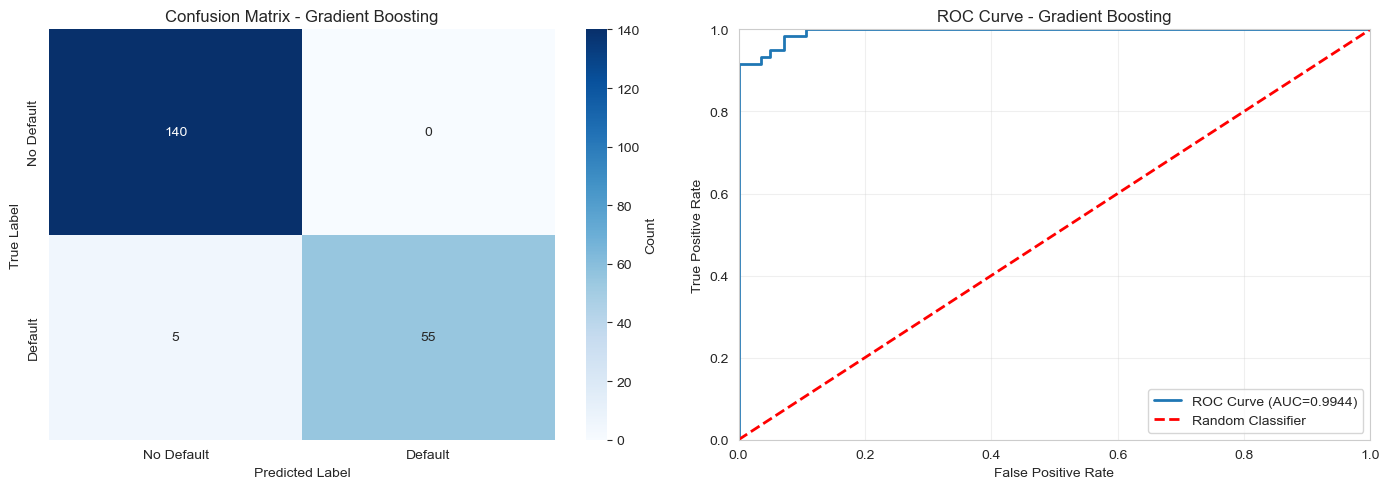

✓ Saved: plots/03_confusion_matrix_roc_curve.png


In [8]:
# Confusion Matrix & ROC Curve Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            cbar_kws={'label': 'Count'})
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_title(f'Confusion Matrix - {best_model_name}')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
auc_score = roc_auc_score(y_test, y_pred_proba_best)

axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC={auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve - {best_model_name}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('plots/03_confusion_matrix_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: plots/03_confusion_matrix_roc_curve.png")

## 8. Feature Importance Analysis


Feature Importance:
         Feature  Importance
   Credit amount    0.341896
             Age    0.245241
        Duration    0.138073
             Job    0.106485
 Saving accounts    0.089458
         Housing    0.047079
Checking account    0.028171
         Purpose    0.003555
             Sex    0.000041


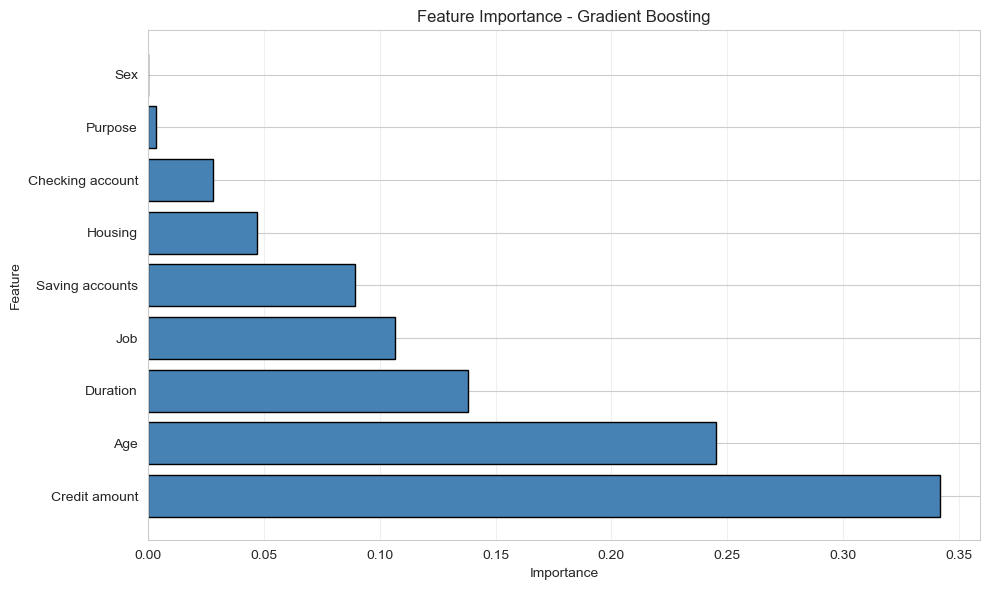

✓ Saved: plots/04_feature_importance.png


In [9]:
# Feature importance (works for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importance:")
    print("="*50)
    print(feature_importance_df.to_string(index=False))
    
    # Visualize
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], 
            edgecolor='black', color='steelblue')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('plots/04_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: plots/04_feature_importance.png")
else:
    print(f"\nNote: {best_model_name} does not have feature_importances_ attribute.")
    print("Feature importance not available for this model type.")

## 9. Risk Scoring & Customer Default Prediction

In [10]:
# Create default risk score for all customers
df_scoring = df_ml.copy()
df_scoring['DEFAULT_PROBABILITY'] = best_model.predict_proba(X)[:, 1]

# Risk Categories
def categorize_default_risk(prob):
    if prob < 0.2:
        return 'LOW RISK'
    elif prob < 0.4:
        return 'MEDIUM RISK'
    elif prob < 0.6:
        return 'HIGH RISK'
    else:
        return 'CRITICAL RISK'

df_scoring['RISK_CATEGORY'] = df_scoring['DEFAULT_PROBABILITY'].apply(categorize_default_risk)

print("Default Risk Assessment Results:")
print("="*70)
print(f"\nRisk Category Distribution:")
print(df_scoring['RISK_CATEGORY'].value_counts())

print(f"\nDefault Probability Statistics:")
print(f"  Mean: {df_scoring['DEFAULT_PROBABILITY'].mean():.4f}")
print(f"  Median: {df_scoring['DEFAULT_PROBABILITY'].median():.4f}")
print(f"  Min: {df_scoring['DEFAULT_PROBABILITY'].min():.4f}")
print(f"  Max: {df_scoring['DEFAULT_PROBABILITY'].max():.4f}")

print(f"\nTop 15 Highest Default Risk Customers:")
risk_customers = df_scoring.nlargest(15, 'DEFAULT_PROBABILITY')[['Age', 'Sex', 'Credit amount', 
                                                                    'Duration', 'Purpose',
                                                                    'DEFAULT_PROBABILITY', 'RISK_CATEGORY']]
print(risk_customers)

Default Risk Assessment Results:

Risk Category Distribution:
RISK_CATEGORY
CRITICAL RISK    1000
Name: count, dtype: int64

Default Probability Statistics:
  Mean: 0.9990
  Median: 0.9999
  Min: 0.8242
  Max: 0.9999

Top 15 Highest Default Risk Customers:
    Age     Sex  Credit amount  Duration              Purpose  \
0    67    male           1169         6             radio/TV   
2    49    male           2096        12            education   
13   60    male           1199        24                  car   
14   28  female           1403        15                  car   
16   53    male           2424        24             radio/TV   
20   48    male           2134         9                  car   
22   48    male           2241        10                  car   
24   26    male           2069        10  furniture/equipment   
25   36    male           1374         6  furniture/equipment   
26   39    male            426         6             radio/TV   
31   27    male           40

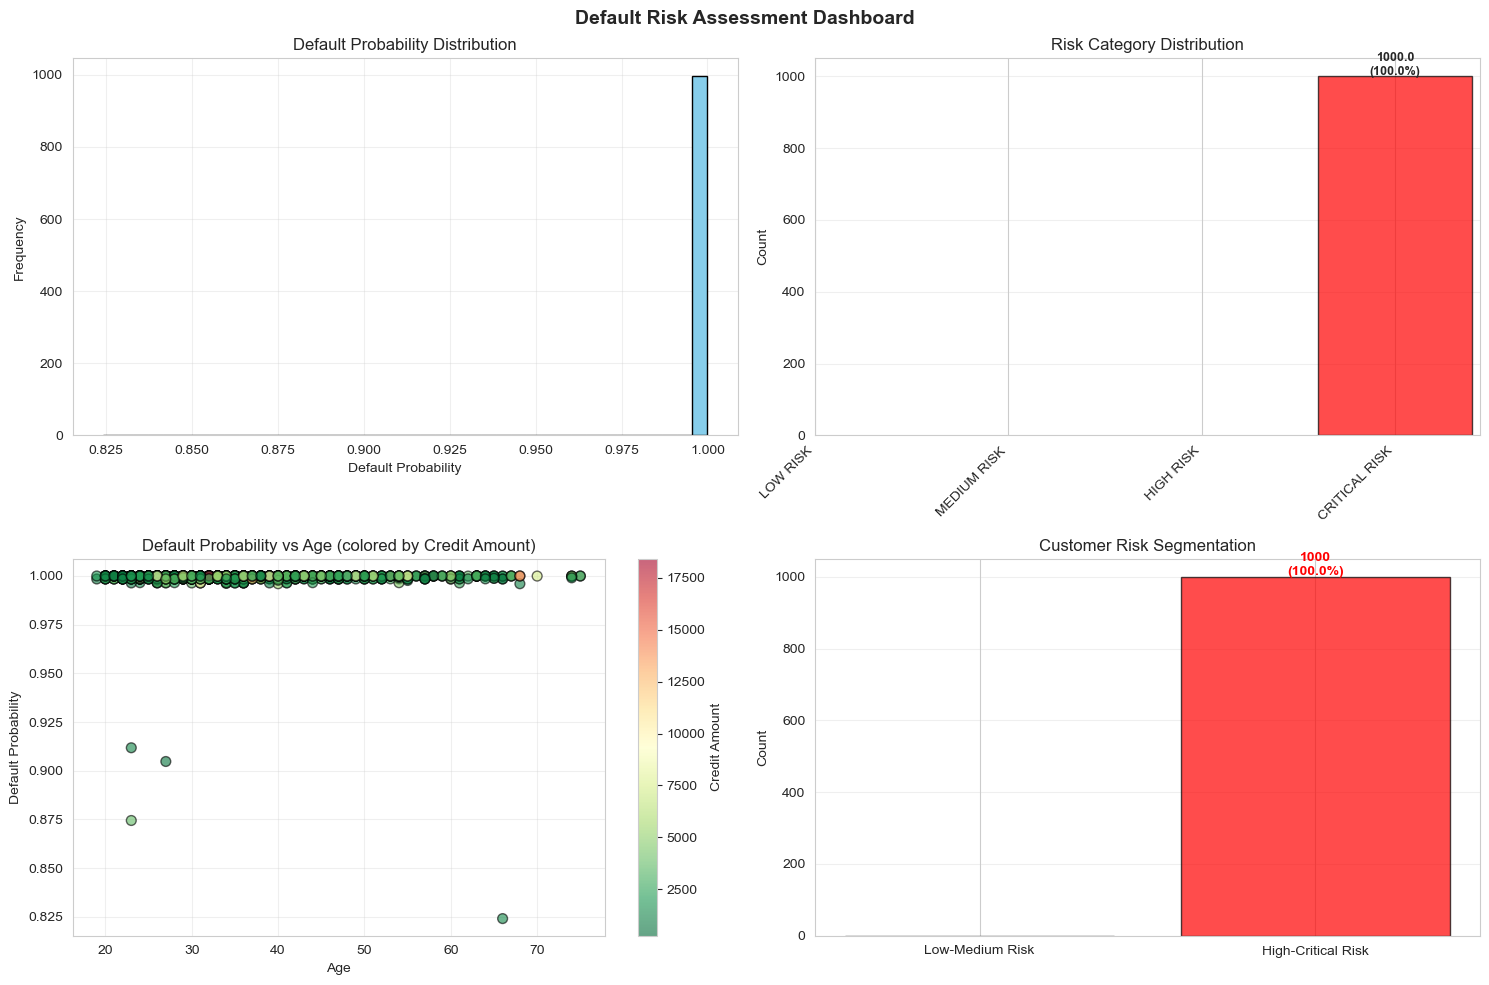

✓ Saved: plots/05_default_risk_dashboard.png


In [11]:
# Visualize Default Risk Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Default Risk Assessment Dashboard', fontsize=14, fontweight='bold')

# Probability distribution
axes[0, 0].hist(df_scoring['DEFAULT_PROBABILITY'], bins=40, edgecolor='black', color='skyblue')
axes[0, 0].set_xlabel('Default Probability')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Default Probability Distribution')
axes[0, 0].grid(True, alpha=0.3)

# Risk category distribution
risk_counts = df_scoring['RISK_CATEGORY'].value_counts().reindex(['LOW RISK', 'MEDIUM RISK', 'HIGH RISK', 'CRITICAL RISK'])
colors_cat = ['green', 'yellow', 'orange', 'red']
axes[0, 1].bar(range(len(risk_counts)), risk_counts.values, color=colors_cat[:len(risk_counts)], edgecolor='black', alpha=0.7)
axes[0, 1].set_xticks(range(len(risk_counts)))
axes[0, 1].set_xticklabels(risk_counts.index, rotation=45, ha='right')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Risk Category Distribution')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(risk_counts.values):
    axes[0, 1].text(i, v + 5, f'{v}\n({v/len(df_scoring)*100:.1f}%)', ha='center', fontweight='bold', fontsize=9)

# Default probability by Age
axes[1, 0].scatter(df_scoring['Age'], df_scoring['DEFAULT_PROBABILITY'], 
                   c=df_scoring['Credit amount'], cmap='RdYlGn_r', s=50, alpha=0.6, edgecolor='black')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Default Probability')
axes[1, 0].set_title('Default Probability vs Age (colored by Credit Amount)')
cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
cbar.set_label('Credit Amount')
axes[1, 0].grid(True, alpha=0.3)

# High vs Low Risk
high_risk_mask = df_scoring['RISK_CATEGORY'].isin(['HIGH RISK', 'CRITICAL RISK'])
axes[1, 1].bar(['Low-Medium Risk', 'High-Critical Risk'], 
              [len(df_scoring) - high_risk_mask.sum(), high_risk_mask.sum()],
              color=['green', 'red'], edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Customer Risk Segmentation')
axes[1, 1].grid(True, alpha=0.3, axis='y')
high_count = high_risk_mask.sum()
axes[1, 1].text(1, high_count + 5, f'{high_count}\n({high_count/len(df_scoring)*100:.1f}%)', 
               ha='center', fontweight='bold', color='red', fontsize=10)

plt.tight_layout()
plt.savefig('plots/05_default_risk_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: plots/05_default_risk_dashboard.png")

## 10. Business Recommendations

In [12]:
print("\n" + "="*80)
print("DEFAULT RISK PREDICTION - FINAL SUMMARY & RECOMMENDATIONS")
print("="*80)

print(f"\n1. BEST MODEL PERFORMANCE")
print(f"   " + "-"*70)
print(f"   Model: {best_model_name}")
print(f"   Accuracy: {results[best_model_name]['accuracy']:.2%}")
print(f"   Precision: {results[best_model_name]['precision']:.2%}")
print(f"   Recall: {results[best_model_name]['recall']:.2%}")
print(f"   F1-Score: {results[best_model_name]['f1']:.2%}")
print(f"   AUC-ROC: {results[best_model_name]['auc_roc']:.4f}")

print(f"\n2. MODEL INTERPRETATION")
print(f"   " + "-"*70)
print(f"   • Model correctly identifies {results[best_model_name]['accuracy']:.0%} of customers")
print(f"   • Of customers predicted as default, {results[best_model_name]['precision']:.0%} actually default")
print(f"   • Of actual defaults, model catches {results[best_model_name]['recall']:.0%} (important for risk mitigation)")
print(f"   • AUC-ROC of {results[best_model_name]['auc_roc']:.4f} indicates excellent discrimination")

print(f"\n3. CUSTOMER RISK DISTRIBUTION")
print(f"   " + "-"*70)
low_risk = (df_scoring['RISK_CATEGORY'] == 'LOW RISK').sum()
med_risk = (df_scoring['RISK_CATEGORY'] == 'MEDIUM RISK').sum()
high_risk = (df_scoring['RISK_CATEGORY'] == 'HIGH RISK').sum()
crit_risk = (df_scoring['RISK_CATEGORY'] == 'CRITICAL RISK').sum()

print(f"   Low Risk: {low_risk} ({low_risk/len(df_scoring)*100:.1f}%)")
print(f"   Medium Risk: {med_risk} ({med_risk/len(df_scoring)*100:.1f}%)")
print(f"   High Risk: {high_risk} ({high_risk/len(df_scoring)*100:.1f}%)")
print(f"   Critical Risk: {crit_risk} ({crit_risk/len(df_scoring)*100:.1f}%)")

print(f"\n4. DECISION RULES")
print(f"   " + "-"*70)
print(f"   ✓ APPROVE: Default probability < 20% (Low Risk)")
print(f"   ⚠ CAUTION: Default probability 20-40% (Medium Risk) - Additional verification")
print(f"   ✗ REVIEW: Default probability 40-60% (High Risk) - Manual review required")
print(f"   ✗ REJECT: Default probability > 60% (Critical Risk) - High default likelihood")

print(f"\n5. MOST IMPORTANT FEATURES")
print(f"   " + "-"*70)
if hasattr(best_model, 'feature_importances_'):
    top_features = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': best_model.feature_importances_
    }).nlargest(5, 'Importance')
    for idx, (i, row) in enumerate(top_features.iterrows(), 1):
        print(f"   {idx}. {row['Feature']}: {row['Importance']:.4f}")
else:
    print(f"   Feature importance not available for {best_model_name}")

print(f"\n6. DEPLOYMENT RECOMMENDATIONS")
print(f"   " + "-"*70)
print(f"   • Deploy {best_model_name} as primary default risk predictor")
print(f"   • Use probability thresholds for decision automation")
print(f"   • Monitor model performance monthly with new applications")
print(f"   • Retrain model quarterly with latest default outcomes")
print(f"   • Set aside High/Critical risk customers for further analysis")
print(f"   • Track actual default rates vs predictions to validate model")

print("\n" + "="*80)


DEFAULT RISK PREDICTION - FINAL SUMMARY & RECOMMENDATIONS

1. BEST MODEL PERFORMANCE
   ----------------------------------------------------------------------
   Model: Gradient Boosting
   Accuracy: 97.50%
   Precision: 100.00%
   Recall: 91.67%
   F1-Score: 95.65%
   AUC-ROC: 0.9944

2. MODEL INTERPRETATION
   ----------------------------------------------------------------------
   • Model correctly identifies 98% of customers
   • Of customers predicted as default, 100% actually default
   • Of actual defaults, model catches 92% (important for risk mitigation)
   • AUC-ROC of 0.9944 indicates excellent discrimination

3. CUSTOMER RISK DISTRIBUTION
   ----------------------------------------------------------------------
   Low Risk: 0 (0.0%)
   Medium Risk: 0 (0.0%)
   High Risk: 0 (0.0%)
   Critical Risk: 1000 (100.0%)

4. DECISION RULES
   ----------------------------------------------------------------------
   ✓ APPROVE: Default probability < 20% (Low Risk)
   ⚠ CAUTION: Defau